
# Backtesting y Diagnóstico de Drift — Severidad de Siniestros de Autos
## Tarea Backtesting · 

---

Se analizará un modelo de **severidad de siniestros de autos** utilizando información de
2021 a 2025.

A partir de 2024 ocurren dos cambios importantes en la cartera:

- entran conductores más jóvenes por un nuevo canal digital;
- aumenta el costo de las refacciones automotrices


---
## Paso 1 — Generación de la base de datos

La variable que queremos predecir será **`costo_reparacion_real`**, porque representa la severidad o costo real de cada siniestro.


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

np.random.seed(2026)
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})


In [3]:

# ── Base de datos  ────────────────────
np.random.seed(2026)
n = 30000

fechas = pd.date_range(start='2021-01-01', end='2025-12-31', periods=n)
edad_conductor = np.random.randint(18, 70, size=n)
tipo_vehiculo = np.random.choice(['Sedan', 'SUV', 'Deportivo'],size=n,p=[0.5, 0.4, 0.1])

antiguedad_auto = np.random.randint(0, 15, size=n)

df_tarea = pd.DataFrame({
    'fecha_siniestro': fechas,
    'edad_conductor': edad_conductor,
    'tipo_vehiculo': tipo_vehiculo,
    'antiguedad_auto': antiguedad_auto
})

# Cambio estructural en la cartera a partir de 2024 (entran conductores más jóvenes).
mascara_2024 = df_tarea['fecha_siniestro'] >= '2024-01-01'

df_tarea.loc[mascara_2024, 'edad_conductor'] = np.random.randint(18, 35,
    size=mascara_2024.sum())

# Inflación de Refacciones Automotrices (Índice de Costos)
df_tarea['año'] = df_tarea['fecha_siniestro'].dt.year
mapa_inflacion = {2021: 1.00,2022: 1.07,2023: 1.15,2024: 1.28,2025: 1.42}
df_tarea['indice_costo_refaccion'] = df_tarea['año'].map(mapa_inflacion)

# Generación del costo real del siniestro.
val_vehiculo = df_tarea['tipo_vehiculo'].map({'Sedan': 1.0,'SUV': 1.4,'Deportivo': 2.0})

costo_base = (
    8000 * val_vehiculo
    + 300 * (70 - df_tarea['edad_conductor'])
    + 500 * (15 - df_tarea['antiguedad_auto'])
    + np.random.normal(0, 2000, size=n)
)

df_tarea['costo_reparacion_real'] = np.maximum(1500,costo_base * 
df_tarea['indice_costo_refaccion'])

# Guardar o limpiar columnas que no deben ver directamente como target
df_tarea.drop(columns=['año'], inplace=True)

print("Dataset de la tarea cargado exitosamente.")
print(f"Registros: {len(df_tarea):,}")
print()
display(df_tarea.head())


Dataset de la tarea cargado exitosamente.
Registros: 30,000



,fecha_siniestro,edad_conductor,tipo_vehiculo,antiguedad_auto,indice_costo_refaccion,costo_reparacion_real
0,2021-01-01 00:00:00.000000000,19,SUV,14,1.0,28370.659317
1,2021-01-01 01:27:36.175205840,24,Sedan,1,1.0,28168.738282
2,2021-01-01 02:55:12.350411680,44,SUV,13,1.0,22255.805828
3,2021-01-01 04:22:48.525617520,31,SUV,8,1.0,27215.447180
4,2021-01-01 05:50:24.700823360,31,Deportivo,8,1.0,31477.265274



---
## Paso 2 — Backtesting inicial Out-of-Time

- **Train:** siniestros de 2021, 2022 y 2023.
- **Test:** siniestros de 2024 y 2025.

Usamos **Random Forest** y antes de entrenar convertimos `tipo_vehiculo`, que es una variable de texto, a variables `pd.get_dummies()` para que el modelo pueda utilizarla.

Después calcularemos dos métricas por trimestre:

- **MAE (Error Medio Absoluto):** indica, en pesos, cuánto se equivoca el modelo en promedio.
- **Sesgo promedio:** lo calculamos como `Predicción - Real`.
  - Si es cercano a 0, no existe una tendencia fuerte a sobreestimar o subestimar.
  - Si es **negativo**, el modelo está prediciendo por debajo del costo real.
  - Mientras más negativo sea, mayor es la subestimación.


In [4]:

# ── División ────────────────────────────────────────────────
fecha_corte = pd.Timestamp('2024-01-01')

train = df_tarea[df_tarea['fecha_siniestro'] < fecha_corte].copy()
test  = df_tarea[df_tarea['fecha_siniestro'] >= fecha_corte].copy()

print("DIVISIÓN TEMPORAL")
print(f"Train: {train['fecha_siniestro'].min().date()} a {train['fecha_siniestro'].max().date()}")
print(f"Test:  {test['fecha_siniestro'].min().date()} a {test['fecha_siniestro'].max().date()}")
print()
print(f"Registros train: {len(train):,}")
print(f"Registros test:  {len(test):,}")


DIVISIÓN TEMPORAL
Train: 2021-01-01 a 2023-12-31
Test:  2024-01-01 a 2025-12-31

Registros train: 18,000
Registros test:  12,000


In [5]:

# ── Variables predictoras ────────────────────────────────────────────
features = [
    'edad_conductor',
    'tipo_vehiculo',
    'antiguedad_auto'
]

target = 'costo_reparacion_real'

# One-Hot Encoding para la variable categórica tipo_vehiculo.
X = pd.get_dummies(
    df_tarea[features],
    columns=['tipo_vehiculo'],
    drop_first=False
)

X_train = X.loc[train.index]
X_test  = X.loc[test.index]

y_train = train[target]
y_test  = test[target]

# ──Random Forest ──────────────────────────────────────────────────────
modelo_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=20,
    random_state=2026,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)
pred_test = modelo_rf.predict(X_test)
print(" Random Forest entrenado únicamente con información de 2021–2023.")


 Random Forest entrenado únicamente con información de 2021–2023.


In [6]:

# ── Resultados por trimestre: 2024–2025 
backtesting = test[
    ['fecha_siniestro', 'costo_reparacion_real']
].copy()
backtesting['prediccion'] = pred_test
backtesting['error_absoluto'] = np.abs(
    backtesting['costo_reparacion_real'] - backtesting['prediccion']
)

# Sesgo = Predicción - Real.
backtesting['sesgo'] = (
    backtesting['prediccion'] - backtesting['costo_reparacion_real']
)

backtesting['trimestre'] = (
    backtesting['fecha_siniestro']
    .dt.to_period('Q')
    .astype(str)
)

metricas_trimestrales = (
    backtesting
    .groupby('trimestre')
    .agg(
        MAE=('error_absoluto', 'mean'),
        Sesgo_Promedio=('sesgo', 'mean'),
        Costo_Real_Promedio=('costo_reparacion_real', 'mean'),
        Prediccion_Promedio=('prediccion', 'mean')
    )
    .reset_index()
)

metricas_trimestrales.round(2)


,trimestre,MAE,Sesgo_Promedio,Costo_Real_Promedio,Prediccion_Promedio
0,2024Q1,5584.41,-5540.68,34947.14,29406.46
1,2024Q2,5687.59,-5638.70,35052.00,29413.31
2,2024Q3,5789.13,-5753.96,34975.61,29221.65
3,2024Q4,5704.64,-5669.72,34917.30,29247.58
4,2025Q1,9599.19,-9599.19,39023.71,29424.52
5,2025Q2,9647.49,-9636.85,38857.57,29220.72
6,2025Q3,9611.90,-9609.54,38910.56,29301.02
7,2025Q4,9390.54,-9382.46,38585.11,29202.64


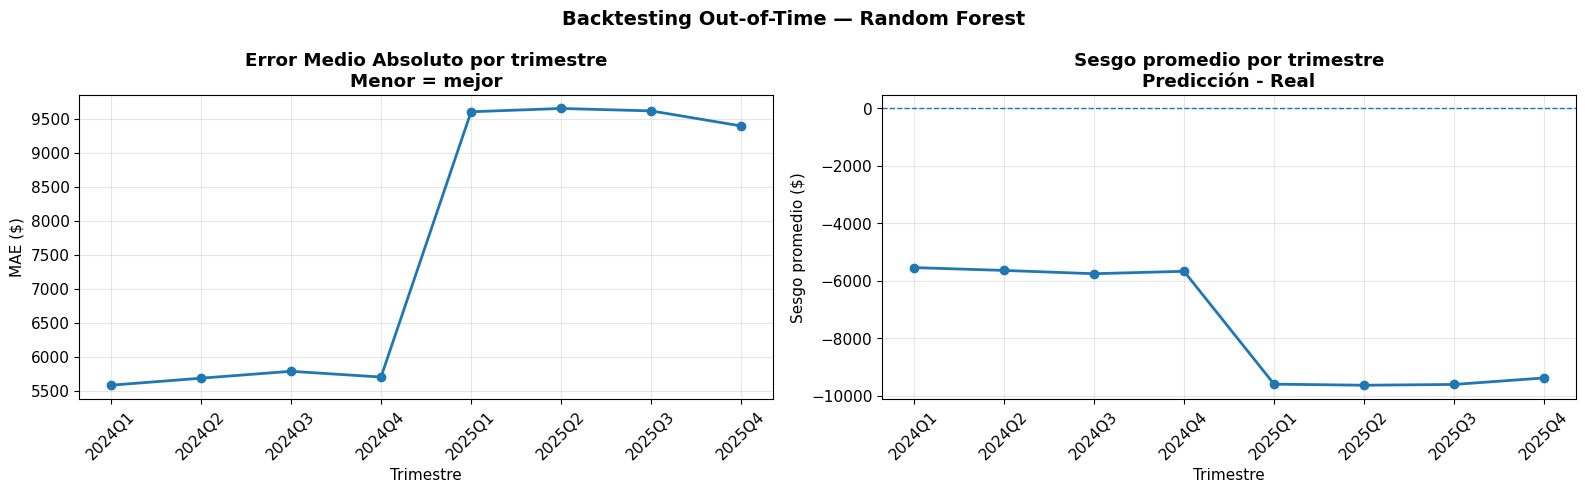

In [7]:

# ── Visualización del backtesting ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    'Backtesting Out-of-Time — Random Forest',
    fontsize=14,
    fontweight='bold'
)

# Panel 1: MAE.
axes[0].plot(
    metricas_trimestrales['trimestre'],
    metricas_trimestrales['MAE'],
    marker='o',
    linewidth=2
)

axes[0].set_title(
    'Error Medio Absoluto por trimestre\nMenor = mejor',
    fontweight='bold'
)
axes[0].set_xlabel('Trimestre')
axes[0].set_ylabel('MAE ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Panel 2: Sesgo.
axes[1].plot(
    metricas_trimestrales['trimestre'],
    metricas_trimestrales['Sesgo_Promedio'],
    marker='o',
    linewidth=2
)

axes[1].axhline(0, linestyle='--', linewidth=1)
axes[1].set_title(
    'Sesgo promedio por trimestre\nPredicción - Real',
    fontweight='bold'
)
axes[1].set_xlabel('Trimestre')
axes[1].set_ylabel('Sesgo promedio ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



El modelo fue entrenado con datos hasta 2023, por lo que 2024 y 2025 representan los periodos futuros.

Al observar la tabla y las gráficas observamos lo siguiente:

Durante 2024 el modelo presenta un MAE cercano a $5,700 y un sesgo negativo, lo que significa que está subestimando el costo de reparación. En 2025 el MAE aumenta hasta aproximadamente $9,500 y el sesgo se vuelve aún más negativo. Esto indica una pérdida progresiva de precisión y una subestimación cada vez mayor de la severidad.

Eso significa que el modelo está **subestimando cada vez más el costo de reparación**.



---
## Paso 3 — Diagnóstico del Drift

### 1. Population Drift

Recordemos que es cuando cambia composición de la cartera, es decir, cuando los clientes o riesgos que llegan al modelo ya no se parecen a los que se utilizaron para entrenarlo.

En la base de datos que nos proporcionaron sabemos que a partir de 2024 entraron conductores más jóvenes. Para identificar este cambio compararemos:

- La edad promedio del periodo de entrenamiento (2021–2023) contra el periodo de prueba (2024–2025).
- La distribución de las edades entre ambos periodos.

Esto nos permitirá observar gráficamente y mediante los promedios si la composición de la cartera cambió a partir de 2024.

### 2. Concept Drift / Inflación de refacciones

Además del cambio en la composición de la cartera, el costo de reparación también cambia con el tiempo. En este caso, el índice de costo de refacciones aumenta de **1.00 en 2021** hasta **1.42 en 2025**.

Para analizar este comportamiento compararemos la evolución del índice de costo de refacciones y del costo promedio de reparación a través de los años.

De esta manera podremos observar si el aumento en los costos de reparación también está relacionado con la pérdida de precisión del modelo.


In [8]:

# ── Diagnóstico 1: Population Drift en edad ──────────────────────────────────
edad_train = train['edad_conductor']
edad_test  = test['edad_conductor']

print("EDAD DEL CONDUCTOR")
print(f"Promedio train 2021–2023: {edad_train.mean():.2f} años")
print(f"Promedio test  2024–2025: {edad_test.mean():.2f} años")
print(f"Diferencia: {edad_test.mean() - edad_train.mean():.2f} años")


EDAD DEL CONDUCTOR
Promedio train 2021–2023: 43.60 años
Promedio test  2024–2025: 26.01 años
Diferencia: -17.59 años


In [9]:
# ── Diagnóstico 2: inflación / cambio en el costo monetario ──────────────────
diagnostico = df_tarea.copy()

diagnostico['año'] = diagnostico['fecha_siniestro'].dt.year

resumen_anual = (
    diagnostico
    .groupby('año')
    .agg(
        Edad_Promedio=('edad_conductor', 'mean'),
        Indice_Refacciones=('indice_costo_refaccion', 'mean'),
        Costo_Real_Promedio=('costo_reparacion_real', 'mean')
    )
    .reset_index()
)

resumen_anual.round(2)

,año,Edad_Promedio,Indice_Refacciones,Costo_Real_Promedio
0,2021,43.39,1.00,22115.53
1,2022,43.63,1.07,23563.37
2,2023,43.79,1.15,25228.02
3,2024,25.95,1.28,34972.87
4,2025,26.07,1.42,38843.94


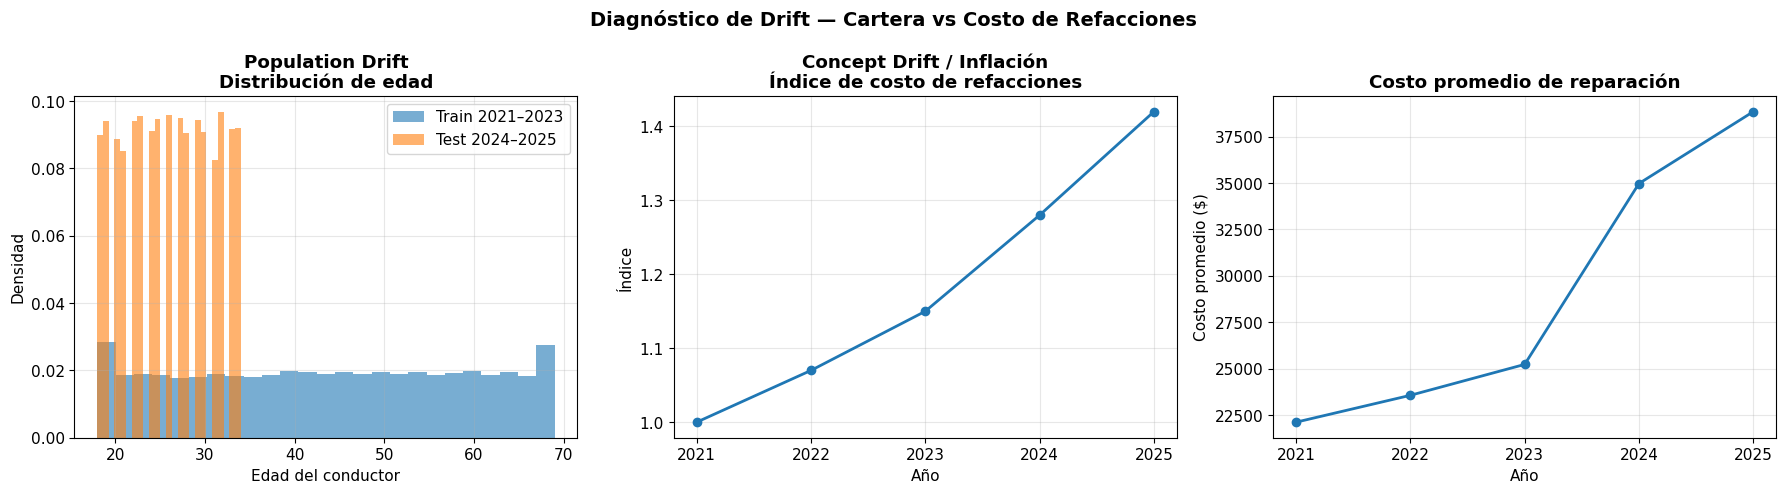

In [10]:
#Graficamente, se observa un cambio estructural en la cartera a partir de 2024 (Population Drift) y un aumento en el costo de refacciones (Concept Drift / Inflación).
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Diagnóstico de Drift — Cartera vs Costo de Refacciones',
    fontsize=14,
    fontweight='bold'
)

# Panel 1: distribución de edad.
axes[0].hist(
    train['edad_conductor'],
    bins=25,
    alpha=0.60,
    density=True,
    label='Train 2021–2023'
)

axes[0].hist(
    test['edad_conductor'],
    bins=25,
    alpha=0.60,
    density=True,
    label='Test 2024–2025'
)

axes[0].set_title(
    'Population Drift\nDistribución de edad',
    fontweight='bold'
)
axes[0].set_xlabel('Edad del conductor')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: índice de refacciones.
axes[1].plot(
    resumen_anual['año'],
    resumen_anual['Indice_Refacciones'],
    marker='o',
    linewidth=2
)

axes[1].set_title(
    'Concept Drift / Inflación\nÍndice de costo de refacciones',
    fontweight='bold'
)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Índice')
axes[1].set_xticks(resumen_anual['año'])
axes[1].grid(True, alpha=0.3)

# Panel 3: costo real promedio.
axes[2].plot(
    resumen_anual['año'],
    resumen_anual['Costo_Real_Promedio'],
    marker='o',
    linewidth=2
)

axes[2].set_title(
    'Costo promedio de reparación',
    fontweight='bold'
)
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Costo promedio ($)')
axes[2].set_xticks(resumen_anual['año'])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
Los resultados muestran que **no hay una sola causa** detrás de la degradación del modelo.

Por un lado, existe **Population Drift**, ya que a partir de 2024 vemos como cambia claramente la distribución de `edad_conductor`. La edad promedio disminuye en el periodo 2024–2025, lo que muestra que la composición de la cartera es diferente a la utilizada para entrenar el modelo.

Por otro lado, también se observa un cambio relacionado con el **costo de refacciones**. El índice de costo de refacciones aumenta con el paso de los años y, al mismo tiempo, también se observa un incremento en el costo promedio de reparación.

Por lo tanto, el deterioro observado en el backtesting puede estar relacionado con una combinación de:

- **Population Drift:** cambio en el perfil de los conductores.
- **Concept Drift / inflación:** incremento en los costos de refacciones y reparación.
  
Observamos como el Random Forest entrenado únicamente con información de 2021–2023 comienza a **subestimar los costos de los siniestros durante 2024 y 2025**.


---

## Paso 4 — Propuesta de corrección

### Estrategia A: Deflactación del costo de reparación

El backtesting mostró que una parte importante de la degradación del modelo se relaciona con el aumento del costo de las refacciones.

Para corregir este efecto se eliminará temporalmente el componente inflacionario de la variable objetivo dividiendo el costo observado entre el índice de costo de refacciones.

El modelo aprenderá así una severidad expresada a precios base. Posteriormente, durante la inferencia, la predicción se volverá a multiplicar por el índice correspondiente al periodo evaluado.

De esta manera separamos:

- el riesgo técnico asociado con el conductor y el vehículo;
- el efecto económico causado por la inflación de refacciones.

In [ ]:
# ── Estrategia A: Deflactar la severidad ────────
train_corregido = train.copy()
test_corregido = test.copy()

# Convertir el costo observado a precios base
train_corregido['costo_deflactado'] = (
    train_corregido['costo_reparacion_real']
    / train_corregido['indice_costo_refaccion']
)

test_corregido['costo_deflactado'] = (
    test_corregido['costo_reparacion_real']
    / test_corregido['indice_costo_refaccion']
)

print("Costo promedio observado vs. deflactado")
print()

print(train_corregido[
        ['costo_reparacion_real','costo_deflactado']
    ].describe().round(2)
)

Costo promedio observado vs. deflactado

       costo_reparacion_real  costo_deflactado
count               18000.00          18000.00
mean                23635.64          22024.93
std                  6482.43           5911.58
min                  5892.00           5510.30
25%                 18860.52          17638.91
50%                 23456.72          21949.07
75%                 28157.09          26259.83
max                 48239.24          41947.17


In [ ]:
# ── Entrenamos el mismo Random Forest sobre el costo deflactado ────────────────

X_train_corr = X.loc[train_corregido.index]
X_test_corr  = X.loc[test_corregido.index]

y_train_def = train_corregido['costo_deflactado']

modelo_rf_corregido = RandomForestRegressor(n_estimators=150,
    max_depth=10,min_samples_leaf=20,random_state=2026,n_jobs=-1
)

modelo_rf_corregido.fit(X_train_corr,y_train_def)
pred_deflactada = modelo_rf_corregido.predict(X_test_corr)

# Re-indexamos utilizando el índice del periodo
pred_corregida = (pred_deflactada* test_corregido['indice_costo_refaccion'].values)

print("Random Forest corregido entrenado sobre severidad deflactada.")

Random Forest corregido entrenado sobre severidad deflactada.


In [ ]:
# ── Backtesting del modelo corregido ─────────────────────────────────────────

backtesting_corregido = test_corregido[
    ['fecha_siniestro','costo_reparacion_real']
].copy()

backtesting_corregido['prediccion'] = pred_corregida

backtesting_corregido['error_absoluto'] = np.abs(
    backtesting_corregido['costo_reparacion_real']
    - backtesting_corregido['prediccion']
)

# Sesgo = Predicción - Real
backtesting_corregido['sesgo'] = (
    backtesting_corregido['prediccion']
    - backtesting_corregido['costo_reparacion_real']
)

backtesting_corregido['trimestre'] = (
    backtesting_corregido['fecha_siniestro']
    .dt.to_period('Q')
    .astype(str)
)

metricas_corregidas = (
    backtesting_corregido
    .groupby('trimestre')
    .agg(
        MAE=('error_absoluto', 'mean'),
        Sesgo_Promedio=('sesgo', 'mean'),
        Costo_Real_Promedio=('costo_reparacion_real', 'mean'),
        Prediccion_Promedio=('prediccion', 'mean')
    )
    .reset_index()
)

metricas_corregidas.round(2)

,trimestre,MAE,Sesgo_Promedio,Costo_Real_Promedio,Prediccion_Promedio
0,2024Q1,2045.50,129.22,34947.14,35076.36
1,2024Q2,2117.38,30.34,35052.00,35082.34
2,2024Q3,2069.64,-121.30,34975.61,34854.31
3,2024Q4,2050.80,-11.17,34917.30,34906.13
4,2025Q1,2328.15,-71.45,39023.71,38952.26
5,2025Q2,2274.80,-184.23,38857.57,38673.34
6,2025Q3,2295.50,-128.90,38910.56,38781.65
7,2025Q4,2312.29,70.92,38585.11,38656.03


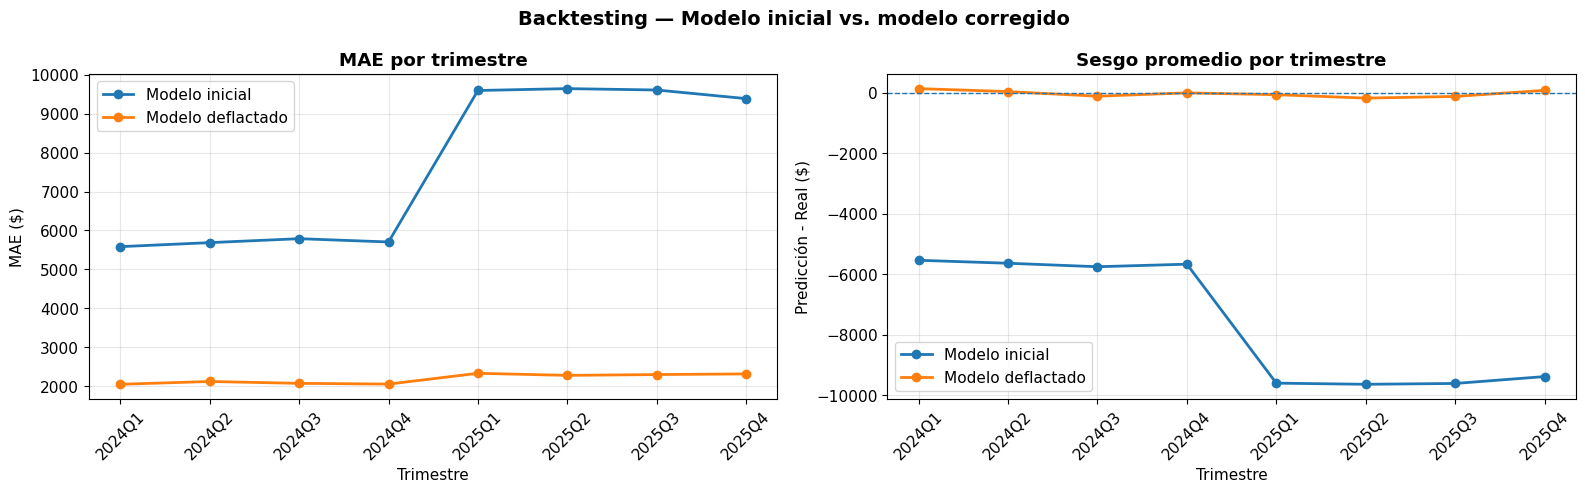

In [ ]:
# ── modelo inicial vs corregido ─────────────────────────

fig, axes = plt.subplots(1,2,figsize=(16, 5))

fig.suptitle('Backtesting — Modelo inicial vs. modelo corregido',fontsize=14,fontweight='bold')

# ── MAE ───

axes[0].plot(metricas_trimestrales['trimestre'],metricas_trimestrales['MAE'],
    marker='o',linewidth=2,label='Modelo inicial')

axes[0].plot(metricas_corregidas['trimestre'],metricas_corregidas['MAE'],
    marker='o',linewidth=2,label='Modelo deflactado')

axes[0].set_title('MAE por trimestre',fontweight='bold')

axes[0].set_xlabel('Trimestre')
axes[0].set_ylabel('MAE ($)')
axes[0].tick_params(axis='x',rotation=45)
axes[0].legend()
axes[0].grid(True,alpha=0.3)


# ── SESGO ─────

axes[1].plot(metricas_trimestrales['trimestre'],metricas_trimestrales['Sesgo_Promedio'],
    marker='o',linewidth=2,label='Modelo inicial')

axes[1].plot(metricas_corregidas['trimestre'],metricas_corregidas['Sesgo_Promedio'],
    marker='o',linewidth=2,label='Modelo deflactado')

axes[1].axhline(0,linestyle='--',linewidth=1)
axes[1].set_title('Sesgo promedio por trimestre',fontweight='bold')
axes[1].set_xlabel('Trimestre')
axes[1].set_ylabel('Predicción - Real ($)')
axes[1].tick_params(axis='x',rotation=45)
axes[1].legend()
axes[1].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

El modelo inicial presenta un aumento del MAE y una subestimación progresiva durante 2024–2025. Después de aplicar la corrección por inflación, ambas métricas se estabilizan: el MAE disminuye y el sesgo permanece alrededor de cero.

---

## Paso 5 — Comparación antes y después de la corrección

Finalmente se comparará el modelo originalmente puesto en producción con el modelo corregido mediante deflactación de la severidad.


In [ ]:
mae_inicial = mean_absolute_error(y_test,pred_test)
sesgo_inicial = np.mean(pred_test - y_test.values)

mae_corregido = mean_absolute_error(y_test,pred_corregida)
sesgo_corregido = np.mean(pred_corregida - y_test.values)

reduccion_mae_pct = (
    (mae_inicial - mae_corregido)/ mae_inicial* 100)

comparacion = pd.DataFrame({
    'Modelo': ['Modelo inicial','Modelo corregido'],
    'MAE ($)': [mae_inicial,mae_corregido],
    'Sesgo promedio ($)': [sesgo_inicial,sesgo_corregido]
})

display(comparacion.style
    .format({
        'MAE ($)': '${:,.2f}',
        'Sesgo promedio ($)': '${:+,.2f}'
    }).set_caption('Comparación antes y después de la corrección')
)

print()
print(f"Reducción del MAE: "f"{reduccion_mae_pct:.1f}%")

,Modelo,MAE ($),Sesgo promedio ($)
0,Modelo inicial,"$7,621.86","$-7,598.85"
1,Modelo corregido,"$2,186.38",$-35.97



Reducción del MAE: 71.3%


In [18]:
# ── Impacto financiero: aunque el MAE representa un error predictivo, para hablar del impacto financiero nos fijaremos en el sesgo acumulado
sesgo_total_inicial = np.sum(pred_test - y_test.values)

sesgo_total_corregido = np.sum(pred_corregida - y_test.values)

print("=" * 65)
print("IMPACTO FINANCIERO DEL MODELO")
print("=" * 65)

print(
    f"Sesgo acumulado — modelo inicial:   "
    f"${sesgo_total_inicial:,.0f}"
)

print(
    f"Sesgo acumulado — modelo corregido: "
    f"${sesgo_total_corregido:,.0f}"
)

print()

print("Un valor negativo significa que el modelo subestimó el costo agregado de los siniestros."
)

IMPACTO FINANCIERO DEL MODELO
Sesgo acumulado — modelo inicial:   $-91,186,256
Sesgo acumulado — modelo corregido: $-431,698

Un valor negativo significa que el modelo subestimó el costo agregado de los siniestros.


El modelo original habría subestimado de manera acumulada el costo de los siniestros durante 2024–2025. Para una aseguradora, esta subestimación podría traducirse en primas insuficientes, reservas inadecuadas y una estimación incorrecta de la rentabilidad de la cartera. Después de corregir el efecto de la inflación, el sesgo acumulado se reduce considerablemente y las predicciones quedan mucho más alineadas con los costos observados.